In [131]:
import polars as pl
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import wandb
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from pynhd import NLDI
import networkx as nx
from pynhd import NHDPlusHR
import requests
import time

In [132]:
api = wandb.Api()
artifact = api.artifact("flood-forecasting/flood-dataset-daily:latest")
artifact_dir = artifact.download()

df = (
    pl.scan_parquet(f"{artifact_dir}/flood_model_daily.parquet")
    .select(["station_name", "site_id", "latitude", "longitude"])
    .unique(subset=["station_name", "site_id"])
    .collect()
    .to_pandas()
)

wandb:   1 of 1 files downloaded.  


In [133]:
print(df.columns)
df = df.rename(columns={"latitude": "lat", "longitude": "lon"})
df = df.groupby(["station_name", "site_id"]).agg({
    "lat": 'first',
    "lon": 'first'
}).reset_index()
df = df.rename(columns={"site_id": "gage_id"})
print(df.head())
gage_ids = set(df["gage_id"].astype(str))
df['gage_id'] = df['gage_id'].astype(str)

Index(['station_name', 'site_id', 'latitude', 'longitude'], dtype='object')
                               station_name          gage_id        lat  \
0   BELLE FOURCHE RIVER NEAR ELM SPRINGS,SD         06438000  44.369989   
1              ANDREWS CREEK-LOCH VALE-RMNP  401723105400000  40.290000   
2                          ANDREWS SPRING 1  401727105400000  40.290818   
3                 ANNIE CREEK NEAR LEAD, SD         06430800  44.327498   
4               ANTELOPE CR NEAR MISSION SD         06463900  43.273782   

          lon  
0 -102.566526  
1 -105.666667  
2 -105.667227  
3 -103.894532  
4 -100.684640  


In [138]:
def safe_request(url, retries=5):
    time.sleep(0.25)
    for i in range(retries):

        r = requests.get(url)

        if r.status_code == 200:
            return r.json()

        if r.status_code == 429:
            time.sleep(2 * (i + 1))  # increasing delay
            continue

        return None

    print(f"Max retries exceeded for URL: {url}")
    return None 

In [139]:
def find_upstream_mainline(gage):

    url = f"https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-{gage}/navigation/UM/nwissite?distance=9999"

    data = safe_request(url)
    if not data:
        return None

    matches = []

    for f in data.get("features", []):

        site = f["properties"]["identifier"].replace("USGS-", "")

        if site != gage and site in gage_ids:
            matches.append((site, f["properties"]["measure"]))

    if matches:
        matches.sort(key=lambda x: x[1])
        return matches[0][0]

    return None

In [140]:
def find_upstream_trib(gage):

    url = f"https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-{gage}/navigation/UT/nwissite?distance=9999"

    data = safe_request(url)
    if not data:
        return None

    matches = []

    for f in data.get("features", []):

        site = f["properties"]["identifier"].replace("USGS-", "")

        if site != gage and site in gage_ids:
            matches.append((site, f["properties"]["measure"]))

    if matches:
        matches.sort(key=lambda x: x[1])
        return matches[0][0]

    return None

In [137]:
print(find_upstream_mainline("06930000"))
df["upstream_gage_mainline"] = df["gage_id"].apply(find_upstream_mainline)

None
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retries exceeded
Max retr

In [141]:
print(find_upstream_trib("06930000"))
df["upstream_gage_trib"] = df["gage_id"].apply(find_upstream_trib)

06929900
Max retries exceeded for URL: https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-06862500/navigation/UT/nwissite?distance=9999
Max retries exceeded for URL: https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-06862700/navigation/UT/nwissite?distance=9999
Max retries exceeded for URL: https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-06714215/navigation/UT/nwissite?distance=9999
Max retries exceeded for URL: https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-06406700/navigation/UT/nwissite?distance=9999
Max retries exceeded for URL: https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-06891810/navigation/UT/nwissite?distance=9999
Max retries exceeded for URL: https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-06638090/navigation/UT/nwissite?distance=9999
Max retries exceeded for URL: https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-06803555/navigation/UT/nwissite?distance=9999
Max retries exceeded for URL: https://api.water.usgs.

In [142]:
print(df[["gage_id","upstream_gage_mainline", "upstream_gage_trib"]])

              gage_id upstream_gage_mainline upstream_gage_trib
0            06438000               06437000           06430850
1     401723105400000                   None               None
2     401727105400000                   None               None
3            06430800                   None               None
4            06463900                   None               None
...               ...                    ...                ...
1044         06327500               06192500           06320000
1045         06309000               06192500           06192900
1046         06186500                   None               None
1047         06192500               06191500           06188000
1048         06329500               06192500           06320000

[1049 rows x 3 columns]


In [143]:
df['upstream_gage'] = np.where(df['upstream_gage_mainline'].notna(), df['upstream_gage_mainline'], df['upstream_gage_trib'])

In [144]:
print(df[['gage_id', 'upstream_gage']].loc[~df['upstream_gage'].isna()])
print(len(df[['gage_id', 'upstream_gage']].loc[~df['upstream_gage'].isna()])/len(df))
print(len(df[['gage_id', 'upstream_gage']].loc[~df['upstream_gage'].isna()]))

       gage_id upstream_gage
0     06438000      06437000
12    06441500      06441000
13    06441000      06440200
14    06406000      06404000
15    06406500      06404000
...        ...           ...
1043  06295000      06192500
1044  06327500      06192500
1045  06309000      06192500
1047  06192500      06191500
1048  06329500      06192500

[567 rows x 2 columns]
0.540514775977121
567


In [145]:
print(df["upstream_gage_mainline"].notna().mean())
print(df["upstream_gage_trib"].notna().mean())
print(
    ((df["upstream_gage_mainline"].notna()) &
     (df["upstream_gage_trib"].notna())).mean()
)

0.45662535748331745
0.5338417540514776
0.449952335557674


In [146]:
df.to_csv("gage_connections.csv", index=False)

In [129]:
url = f"https://api.water.usgs.gov/nldi/linked-data/nwissite/USGS-{"06930000"}/navigation/UM/nwissite?distance=9999"

r = requests.get(url)
data = r.json()
for f in data["features"]:
    site = f["properties"]["identifier"].replace("USGS-", "")
    print(site)
    if site in gage_ids:
        print(f"Found upstream gage on tributary: {site}")

06930000
Found upstream gage on tributary: 06930000
373952092030101
06928730
06928900


In [130]:
print(find_upstream_trib("06930000"))

06929900


Nodes: 775
Edges: 783


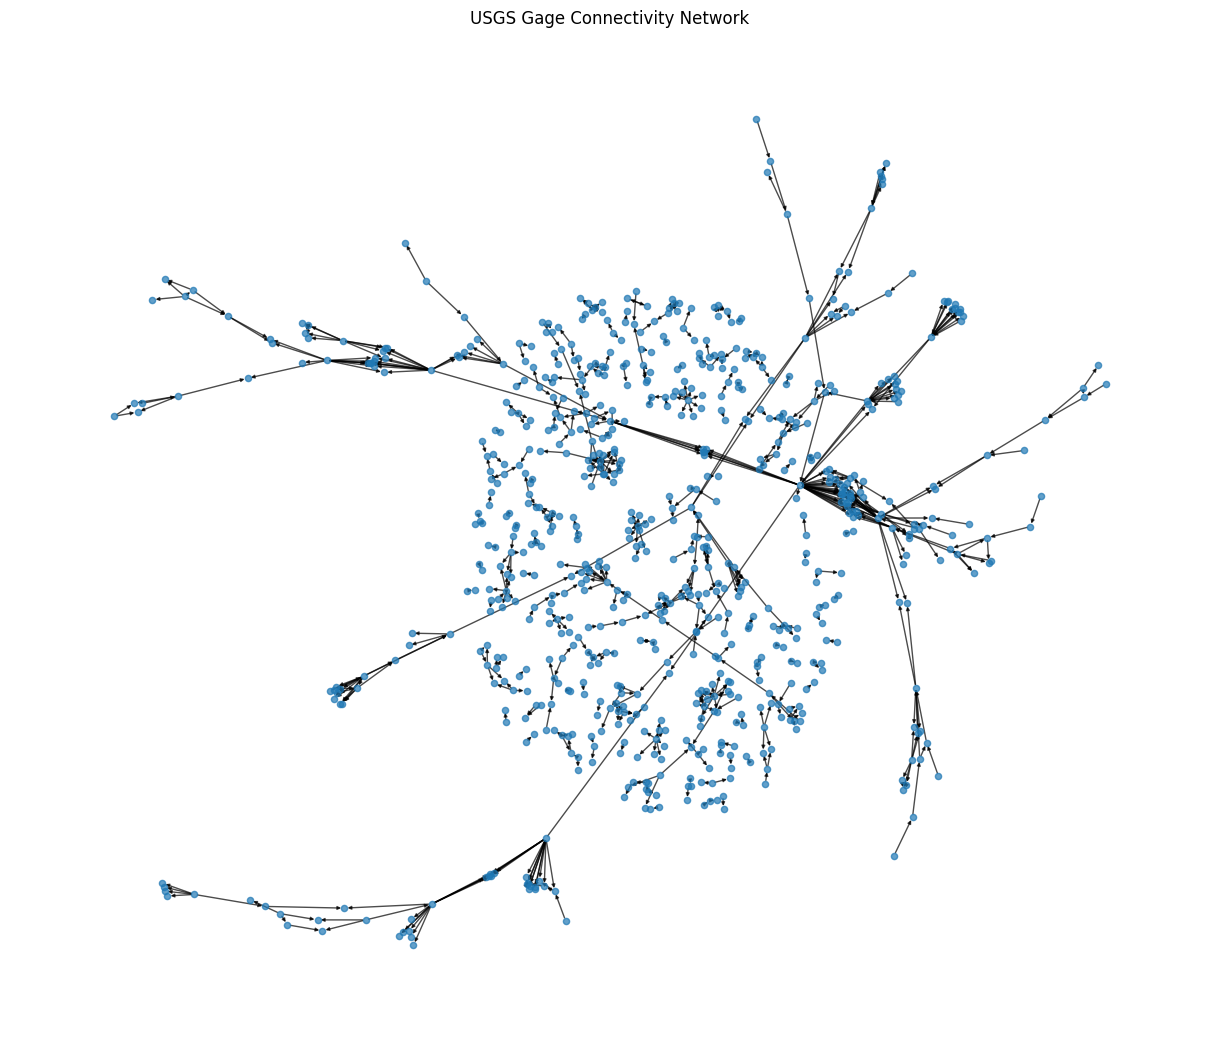

In [147]:
import matplotlib.pyplot as plt
G = nx.DiGraph()

for _, row in df.iterrows():

    gage = row["gage_id"]

    main = row["upstream_gage_mainline"]
    trib = row["upstream_gage_trib"]

    if pd.notna(main):
        G.add_edge(main, gage)

    if pd.notna(trib):
        G.add_edge(trib, gage)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

plt.figure(figsize=(12,10))

pos = nx.spring_layout(G, k=0.15)

nx.draw(
    G,
    pos,
    node_size=20,
    arrowsize=5,
    alpha=0.7,
    with_labels=False
)

plt.title("USGS Gage Connectivity Network")
plt.show()